<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50401 entries, 0 to 50400
Data columns (total 2 columns):
 #   Column                              Non-Null Count  Dtype              
---  ------                              --------------  -----              
 0   utc_timestamp                       50401 non-null  datetime64[ns, UTC]
 1   DE_load_actual_entsoe_transparency  50400 non-null  float64            
dtypes: datetime64[ns, UTC](1), float64(1)
memory usage: 787.6 KB


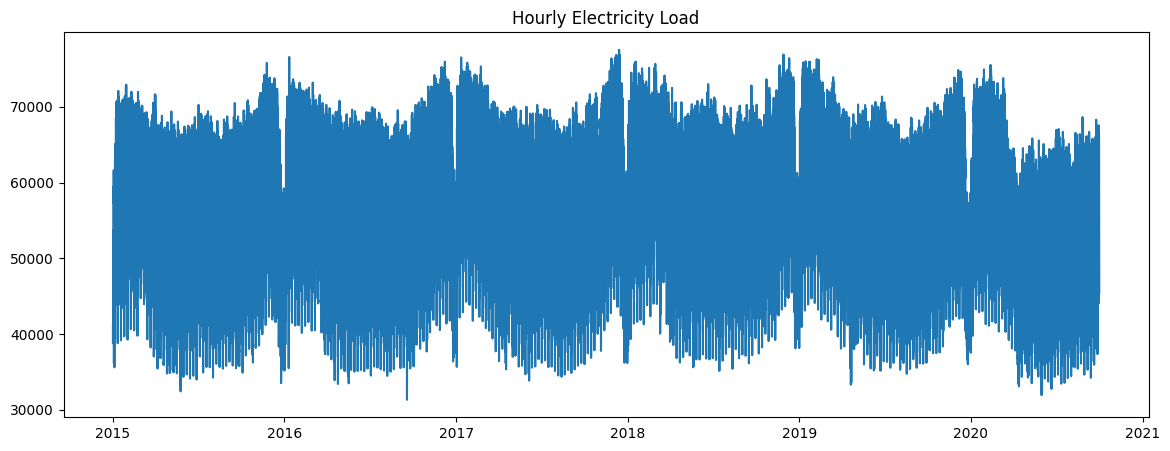

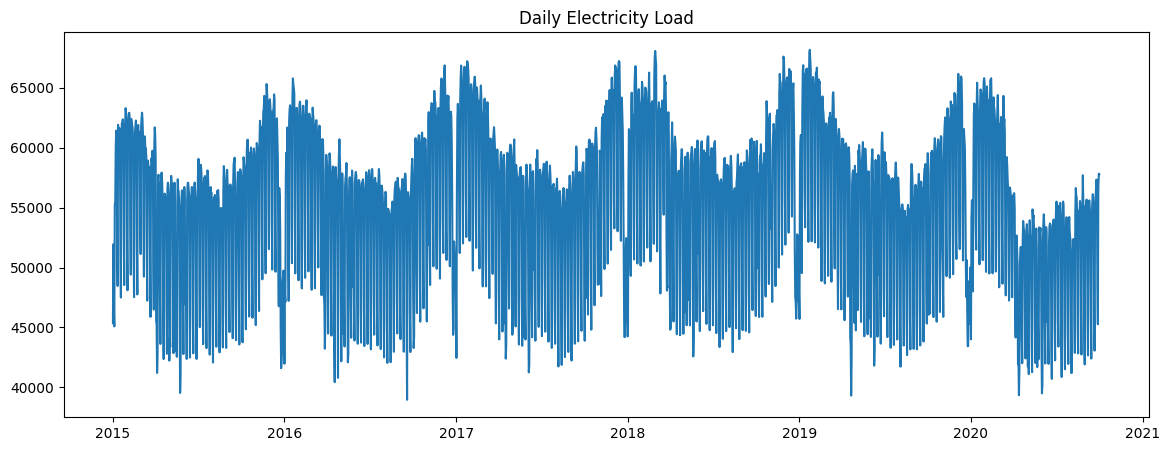

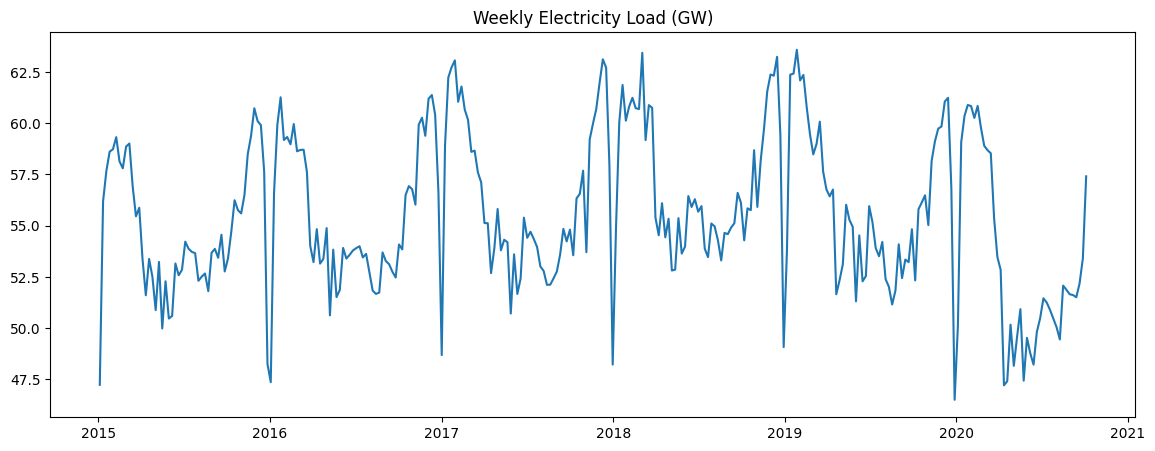

2015-01-04 00:00:00+00:00 2018-10-07 00:00:00+00:00
2018-10-14 00:00:00+00:00 2020-10-04 00:00:00+00:00


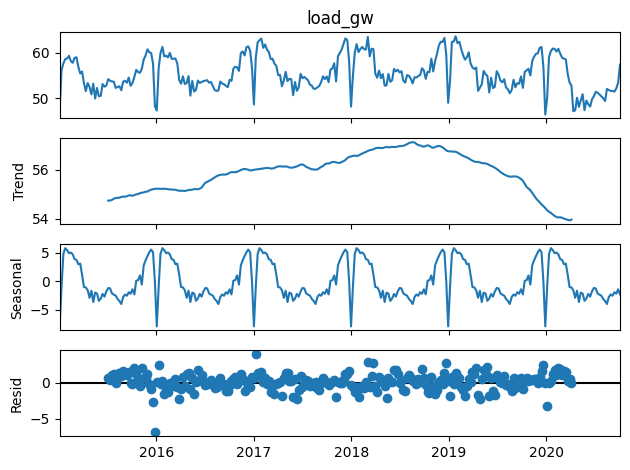

ADF Statistic: -4.047471855678484
p-value: 0.001181349734015439


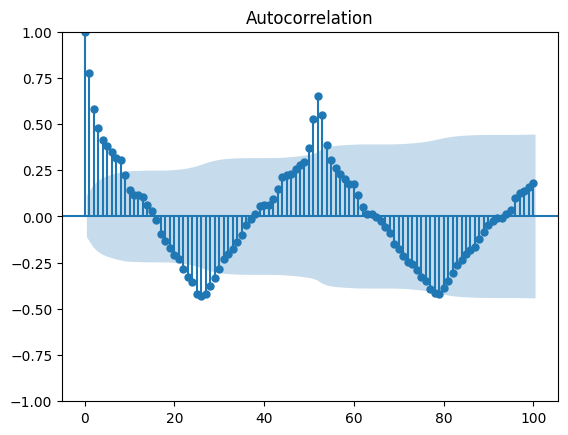

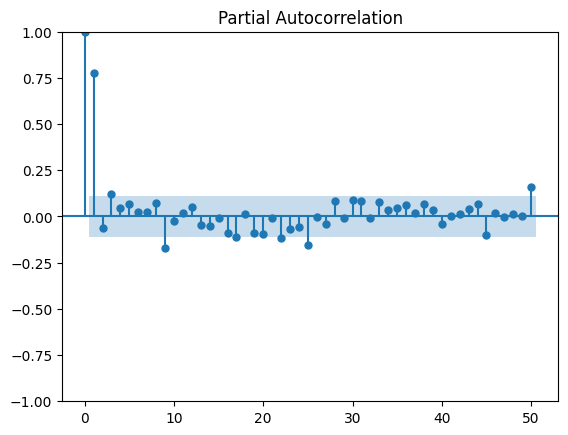

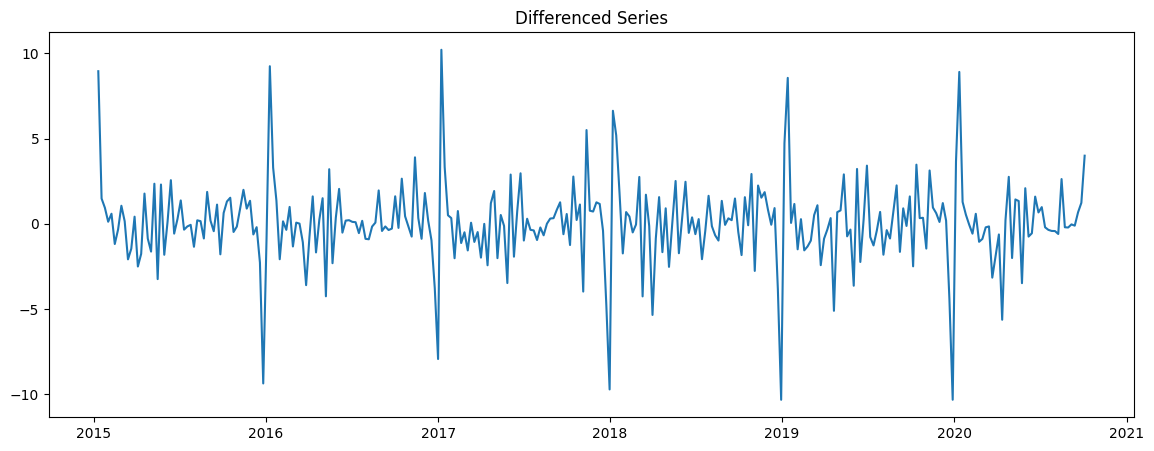

In [3]:
# Advanced Research Topics Assignment 1:  Time series case study:

# Forecasting weekly German electricity demand

# Data: Open Power System Data, Germany electricity load

# Models:
#   1. Simple benchmarks
#   2. SARIMAX
#   3. Feature-based machine learning

# This is an initial workflow for the analyis. The finished pipeline will be significantly more complex than this.# Core

# PART 1 – Data Retrieval, Preparation and EDA

# core
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
!pip install statsmodels
# Classical models
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Feature-based model
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Optional Bayesian model
# pip install pymc arviz
#import pymc as pm
#import arviz as az

# Optional N-BEATS model
# pip install "u8darts[torch]"
#from darts import TimeSeries
#from darts.models import NBEATSModel


RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# 1. Download and prepare Germany electricity load  the dataset

df = pd.read_csv("time_series_60min_singleindex.csv",
    usecols=["utc_timestamp", "DE_load_actual_entsoe_transparency"],
    parse_dates=["utc_timestamp"]
)
# just details about the dataset

df.head()
df.info()
df.describe()

# Data Cleaning and prepare
df = df.rename(columns={
    "utc_timestamp": "date",
    "DE_load_actual_entsoe_transparency": "load_mw"
})

df = df.set_index("date").sort_index()

load = df["load_mw"].astype(float)
load = load[load.notna()]
load = load["2015-01-01":]

# Daily & Weekly Aggregation

daily = load.resample("D").mean()
weekly = load.resample("W").mean() / 1000
weekly = weekly.interpolate("time")
weekly.name = "load_gw"

# Time Series Plot
# Plot ALL time scales

plt.figure(figsize=(14,5))
plt.plot(load)
plt.title("Hourly Electricity Load")
plt.show()

plt.figure(figsize=(14,5))
plt.plot(daily)
plt.title("Daily Electricity Load")
plt.show()

plt.figure(figsize=(14,5))
plt.plot(weekly)
plt.title("Weekly Electricity Load (GW)")
plt.show()

# Train-test split
test_weeks = 104

train = weekly.iloc[:-test_weeks]
test = weekly.iloc[-test_weeks:]

print(train.index.min(), train.index.max())
print(test.index.min(), test.index.max())

# Seasonal Decomposition
# BASIC EDA
# Trend + Seasonality plot

from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(weekly, period=52)
decomposition.plot()
plt.show()


# ADF Test (stationarity)
from statsmodels.tsa.stattools import adfuller

result = adfuller(weekly)

print("ADF Statistic:", result[0])
print("p-value:", result[1])

# ACF + PACF
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plot_acf(weekly, lags=100)
plt.show()

plot_pacf(weekly, lags=50)
plt.show()

# Differencing
weekly_diff = weekly.diff().dropna()

plt.figure(figsize=(14,5))
plt.plot(weekly_diff)
plt.title("Differenced Series")
plt.show()


In [4]:
# part2
# BENCHMARK MODELS
# Set horizon

h = len(test)

# Mean Forecast
mean_forecast = pd.Series(train.mean(), index=test.index)
# Naive Forecast
naive_forecast = pd.Series(train.iloc[-1], index=test.index)
# Seasonal Naive
seasonal_naive = []

history = train.copy()

for date in test.index:
    seasonal_date = date - pd.DateOffset(weeks=52)

    if seasonal_date in history.index:
        value = history.loc[seasonal_date]
    else:
        value = history.iloc[-52]

    seasonal_naive.append(value)

    # update history (walk-forward style)
    history.loc[date] = test.loc[date]

seasonal_naive_forecast = pd.Series(seasonal_naive, index=test.index)





            model       MAE      RMSE      MASE      Bias
2  Seasonal naive  2.063028  2.671877  1.541484  1.440722
1           Naive  3.783203  4.459109  2.826789 -0.882480
0            Mean  3.788833  4.397300  2.830996  0.481006
3           Drift  4.339891  5.117957  3.242743  1.006802


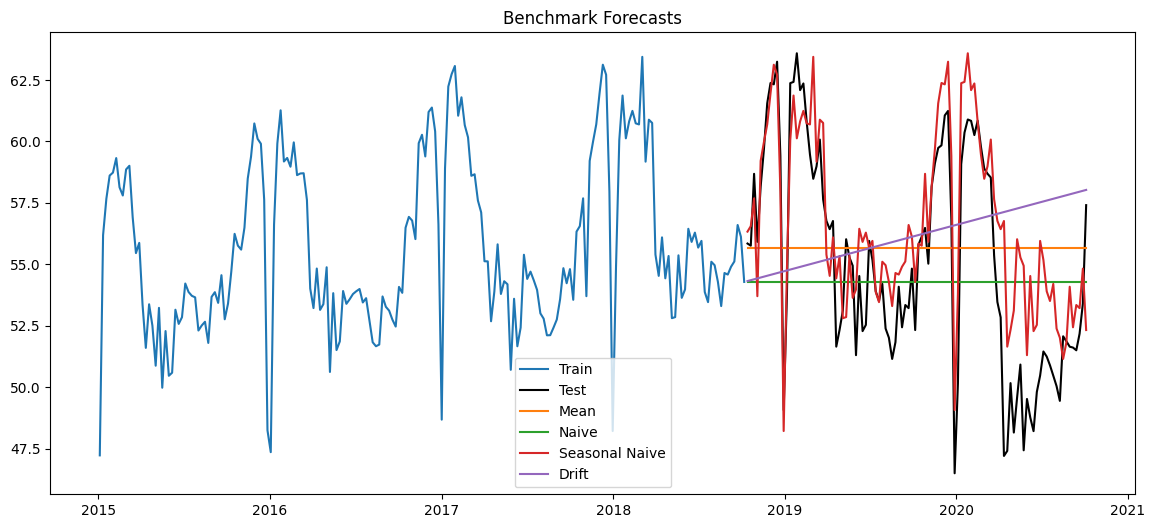

In [5]:
# Evaluation Function
from sklearn.metrics import mean_absolute_error, mean_squared_error
import pandas as pd # Ensure pandas is imported for pd.Series
import numpy as np  # Ensure numpy is imported for np.sqrt, np.mean, np.abs

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def mase(y_true, y_pred, y_train, seasonality=52):
    """
    Mean absolute scaled error.
    Uses seasonal naive in-sample errors as the scaling denominator.
    """
    naive_errors = np.abs(y_train.iloc[seasonality:].values - y_train.iloc[:-seasonality].values)
    scale = naive_errors.mean()
    return np.mean(np.abs(y_true - y_pred)) / scale

def evaluate_forecast(name, y_true, y_pred, y_train):
    y_true = pd.Series(y_true).astype(float)
    y_pred = pd.Series(y_pred, index=y_true.index).astype(float)

    return {
        "model": name,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": rmse(y_true, y_pred),
        "MASE": mase(y_true, y_pred, y_train),
        "Bias": np.mean(y_pred - y_true),
    }

# Removed redundant results initialization and appends from this cell.


results = []

# Drift Forecast
drift_slope = (train.iloc[-1] - train.iloc[0]) / (len(train) - 1)

drift_forecast = pd.Series(
    train.iloc[-1] + drift_slope * np.arange(1, h + 1),
    index=test.index
)

benchmark_forecasts = {
    "Mean": mean_forecast,
    "Naive": naive_forecast,
    "Seasonal naive": seasonal_naive_forecast,
    "Drift": drift_forecast,
}

for name, pred in benchmark_forecasts.items():
    results.append(evaluate_forecast(name, test, pred, train))

    # Drift Forecast
drift = (train.iloc[-1] - train.iloc[0]) / (len(train) - 1)

drift_forecast = pd.Series(
    train.iloc[-1] + drift * np.arange(1, h + 1),
    index=test.index
)

results_df = pd.DataFrame(results)
results_df = results_df.sort_values("MASE")

print(results_df)

plt.figure(figsize=(14,6))

plt.plot(train.index, train, label="Train")
plt.plot(test.index, test, label="Test", color="black")

plt.plot(test.index, mean_forecast, label="Mean")
plt.plot(test.index, naive_forecast, label="Naive")
plt.plot(test.index, seasonal_naive_forecast, label="Seasonal Naive")
plt.plot(test.index, drift_forecast, label="Drift")

plt.title("Benchmark Forecasts")
plt.legend()
plt.show()

In [6]:
# PART 3 – SARIMA MODEL


# Import the SARIMAX class (used to implement SARIMA)
# Import libraries
import itertools
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf
from sklearn.metrics import mean_squared_error

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [7]:
# SARIMA parameter search (AIC)



import itertools
from statsmodels.tsa.statespace.sarimax import SARIMAX

p = range(0, 7)
d = range(0, 3)
q = range(0, 7)

pdq = list(itertools.product(p, d, q))


results_aic = []

best_aic = np.inf
best_order = None


print("Starting SARIMA grid search...")


for order in pdq:

    try:

        model = SARIMAX(
            train,
            order=order,
            seasonal_order=(1,1,1,52),
            trend="c",
            enforce_stationarity=False,
            enforce_invertibility=False
        )


        fit = model.fit(
            disp=False,
            maxiter=50,
            method="lbfgs"
        )


        results_aic.append(
            [order, fit.aic]
        )


        if fit.aic < best_aic:
            best_aic = fit.aic
            best_order = order


        print(
            order,
            "AIC:",
            round(fit.aic, 2)
        )


    except:
        pass



print("\nBest Order:", best_order)
print("Best AIC:", round(best_aic,2))


# Show top 10 models

aic_table = pd.DataFrame(
    results_aic,
    columns=["Order","AIC"]
)

display(
    aic_table.sort_values("AIC").head(10)
)

Starting SARIMA grid search...
(0, 0, 0) AIC: 333.1
(0, 0, 1) AIC: 321.74
(0, 0, 2) AIC: 320.03
(0, 0, 3) AIC: 318.11
(0, 0, 4) AIC: 314.14
(0, 0, 5) AIC: 309.14
(0, 0, 6) AIC: 305.67
(0, 1, 0) AIC: 357.65
(0, 1, 1) AIC: 330.72
(0, 1, 2) AIC: 322.17
(0, 1, 3) AIC: 319.94
(0, 1, 4) AIC: 317.57
(0, 1, 5) AIC: 315.78
(0, 1, 6) AIC: 308.39
(0, 2, 0) AIC: 442.0
(0, 2, 1) AIC: 357.44


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


(0, 2, 2) AIC: 332.16
(0, 2, 3) AIC: 321.25


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


(0, 2, 4) AIC: 319.48


...

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


(6, 2, 5) AIC: 332.45


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


(6, 2, 6) AIC: 320.39

Best Order: (1, 1, 6)
Best AIC: 303.7


,Order,AIC
34,"(1, 1, 6)",303.704238
48,"(2, 0, 6)",304.169820
90,"(4, 0, 6)",305.338022
111,"(5, 0, 6)",305.425696
97,"(4, 1, 6)",305.650864
6,"(0, 0, 6)",305.674879
76,"(3, 1, 6)",305.878221
118,"(5, 1, 6)",306.492622
27,"(1, 0, 6)",307.674994
69,"(3, 0, 6)",308.097451


In [8]:
# Fit final SARIMA model
sarima = SARIMAX(
    train,
    order=best_order,
    seasonal_order=(1,1,1,52),
    trend="c",
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_fit = sarima.fit(disp=False)

print(sarima_fit.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                                      SARIMAX Results                                       
Dep. Variable:                              load_gw   No. Observations:                  197
Model:             SARIMAX(1, 1, 6)x(1, 1, [1], 52)   Log Likelihood                -140.852
Date:                              Thu, 09 Jul 2026   AIC                            303.704
Time:                                      17:53:14   BIC                            330.573
Sample:                                  01-04-2015   HQIC                           314.512
                                       - 10-07-2018                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     -0.0082      0.012     -0.712      0.477      -0.031       0.014
ar.L1          0.38

In [ ]:
# Forecast + RMSE
h = len(test)

forecast = sarima_fit.get_forecast(steps=h)

sarima_mean = forecast.predicted_mean
sarima_ci95 = forecast.conf_int(alpha=0.05)

sarima_mean.index = test.index
sarima_ci95.index = test.index


rmse = np.sqrt(
    mean_squared_error(test, sarima_mean)
)

print("SARIMA RMSE =", rmse)

<Figure size 1000x500 with 0 Axes>

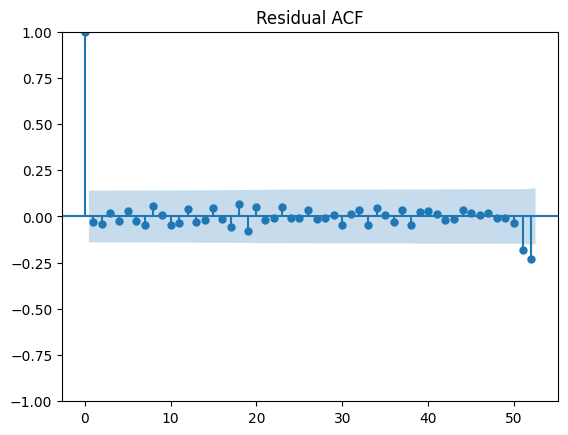

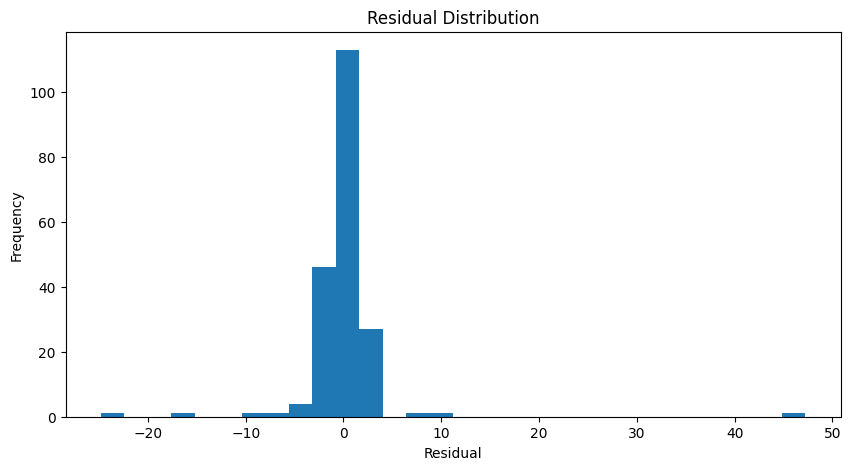

Ljung-Box Test:
     lb_stat  lb_pvalue
20  7.662452   0.993876


In [10]:
# Residual diagnostics
residuals = sarima_fit.resid

plt.figure(figsize=(10,5))
plot_acf(residuals.dropna(), lags=52)
plt.title("Residual ACF")
plt.show()


plt.figure(figsize=(10,5))

plt.hist(residuals.dropna(), bins=30)

plt.title("Residual Distribution")
plt.xlabel("Residual")
plt.ylabel("Frequency")

plt.show()


print("Ljung-Box Test:")
print(acorr_ljungbox(
    residuals.dropna(),
    lags=[20],
    return_df=True
))

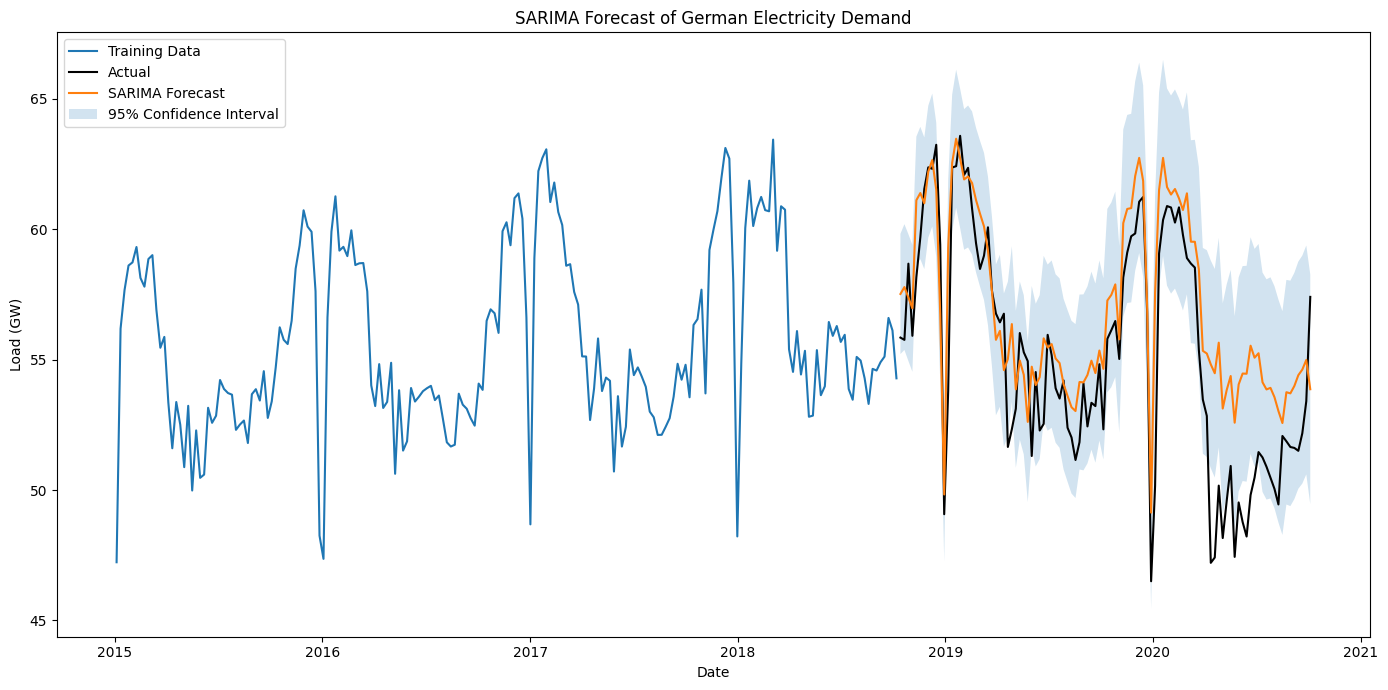

In [11]:
# Forecast plot
plt.figure(figsize=(14,7))

plt.plot(train.index, train, label="Training Data")

plt.plot(test.index, test,
         color="black",
         label="Actual")

plt.plot(test.index,
         sarima_mean,
         label="SARIMA Forecast")


plt.fill_between(
    test.index,
    sarima_ci95.iloc[:,0],
    sarima_ci95.iloc[:,1],
    alpha=0.2,
    label="95% Confidence Interval"
)

plt.title("SARIMA Forecast of German Electricity Demand")
plt.xlabel("Date")
plt.ylabel("Load (GW)")

plt.legend()
plt.tight_layout()
plt.show()

In [12]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def mase(y_true, y_pred, y_train, seasonality=52):
    naive_errors = np.abs(
        y_train.iloc[seasonality:].values -
        y_train.iloc[:-seasonality].values
    )
    scale = naive_errors.mean()
    return np.mean(np.abs(y_true - y_pred)) / scale

def evaluate(name, y_true, y_pred, y_train):
    return {
        "model": name,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": rmse(y_true, y_pred),
        "MASE": mase(y_true, y_pred, y_train),
        "Bias": np.mean(y_pred - y_true),
    }

In [13]:
# Add results table
results.append(
    evaluate_forecast(
        "SARIMA",
        test,
        sarima_mean,
        train
    )
)

results_df = pd.DataFrame(results)

print(results_df.sort_values("MASE"))

            model       MAE      RMSE      MASE      Bias
2  Seasonal naive  2.063028  2.671877  1.541484  1.440722
4          SARIMA  2.133525  2.729623  1.594158  1.727384
1           Naive  3.783203  4.459109  2.826789 -0.882480
0            Mean  3.788833  4.397300  2.830996  0.481006
3           Drift  4.339891  5.117957  3.242743  1.006802


In [14]:

# PART 4 — SARIMAX WITH TEMPERATURE AS EXOGENOUS VARIABLE

# Import libraries
import requests
import pandas as pd
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error, mean_absolute_error


# 1. Download Berlin Temperature Data

def get_open_meteo_temperature(
    latitude=52.52,
    longitude=13.41,
    start_date="2015-01-01",
    end_date="2020-12-31",
):
    """
    Download daily mean temperature from Open-Meteo API.
    Berlin is used as representative location for Germany.
    """

    url = "https://archive-api.open-meteo.com/v1/archive"

    params = {
        "latitude": latitude,
        "longitude": longitude,
        "start_date": start_date,
        "end_date": end_date,
        "daily": "temperature_2m_mean",
        "timezone": "Europe/Berlin",
    }

    response = requests.get(url, params=params)
    response.raise_for_status()

    data = response.json()["daily"]

    temp = pd.DataFrame({
        "date": pd.to_datetime(data["time"]),
        "temperature_2m_mean": data["temperature_2m_mean"]
    })

    temp = temp.set_index("date")

    return temp



# Download temperature matching electricity data period

temp_daily = get_open_meteo_temperature(
    start_date=str(load.index.min().date()),
    end_date=str(load.index.max().date())
)


temp_daily.head()



,temperature_2m_mean
date,
2015-01-01,2.8
2015-01-02,4.6
2015-01-03,3.9
2015-01-04,3.0
2015-01-05,2.7


In [15]:
# 2. Convert Daily Temperature to Weekly Features

# Create weekly dataframe
temp_weekly = pd.DataFrame()

# Weekly average temperature
temp_weekly["temp_mean"] = (
    temp_daily["temperature_2m_mean"]
    .resample("W")
    .mean()
)


# Heating Degree Days (HDD)
base_heat = 15.5

temp_weekly["heating_degree"] = (
    np.maximum(
        base_heat - temp_daily["temperature_2m_mean"],
        0
    )
    .resample("W")
    .sum()
)


# Cooling Degree Days (CDD)
base_cool = 22.0

temp_weekly["cooling_degree"] = (
    np.maximum(
        temp_daily["temperature_2m_mean"] - base_cool,
        0
    )
    .resample("W")
    .sum()
)


# Remove missing rows
temp_weekly = temp_weekly.dropna()


# Display first rows
print(temp_weekly.head())

            temp_mean  heating_degree  cooling_degree
date                                                 
2015-01-04   3.575000            47.7             0.0
2015-01-11   3.885714            81.3             0.0
2015-01-18   4.900000            74.2             0.0
2015-01-25   0.028571           108.3             0.0
2015-02-01   1.414286            98.6             0.0


In [16]:
print(weekly.index[:5])
print(temp_weekly.index[:5])

DatetimeIndex(['2015-01-04 00:00:00+00:00', '2015-01-11 00:00:00+00:00',
               '2015-01-18 00:00:00+00:00', '2015-01-25 00:00:00+00:00',
               '2015-02-01 00:00:00+00:00'],
              dtype='datetime64[ns, UTC]', name='date', freq='W-SUN')
DatetimeIndex(['2015-01-04', '2015-01-11', '2015-01-18', '2015-01-25',
               '2015-02-01'],
              dtype='datetime64[ns]', name='date', freq='W-SUN')


In [17]:
# Convert indexes to datetime
weekly.index = pd.to_datetime(weekly.index)
temp_weekly.index = pd.to_datetime(temp_weekly.index)


# Align both to Sunday week ending
weekly.index = weekly.index.to_period("W-SUN").to_timestamp()
temp_weekly.index = temp_weekly.index.to_period("W-SUN").to_timestamp()

In [18]:
# Convert weekly load Series to DataFrame
weekly_df = weekly.to_frame(name="load_gw")


# Remove timezone from index
weekly_df.index = weekly_df.index.tz_localize(None)


# Ensure temperature index is datetime
temp_weekly.index = pd.to_datetime(temp_weekly.index)


# Merge datasets
feature_df = weekly_df.join(
    temp_weekly,
    how="inner"
)


# Check result
print(feature_df.head())

print("\nDataset shape:")
print(feature_df.shape)

print("\nMissing values:")
print(feature_df.isnull().sum())

              load_gw  temp_mean  heating_degree  cooling_degree
date                                                            
2014-12-29  47.233740   3.575000            47.7             0.0
2015-01-05  56.191101   3.885714            81.3             0.0
2015-01-12  57.672679   4.900000            74.2             0.0
2015-01-19  58.613304   0.028571           108.3             0.0
2015-01-26  58.734030   1.414286            98.6             0.0

Dataset shape:
(301, 4)

Missing values:
load_gw           0
temp_mean         0
heating_degree    0
cooling_degree    0
dtype: int64


In [19]:
y = feature_df["load_gw"]

X = feature_df[
    ["temp_mean", "heating_degree", "cooling_degree"]
]

In [20]:

# 4. SARIMAX Model with Temperature as Exogenous Variables


# Target variable (electricity demand)

y = feature_df["load_gw"]


# Exogenous variables (temperature features)

X = feature_df[
    [
        "temp_mean",
        "heating_degree",
        "cooling_degree"
    ]
]


# Two year forecast horizon

test_weeks = 104


# Train-test split

y_train = y.iloc[:-test_weeks]
y_test = y.iloc[-test_weeks:]


X_train = X.iloc[:-test_weeks]
X_test = X.iloc[-test_weeks:]


print("Training:", y_train.shape)
print("Testing :", y_test.shape)




Training: (197,)
Testing : (104,)


In [30]:
# Build SARIMAX model with exogenous temperature
# Fit SARIMAX with temperature feature

sarimax_temp = SARIMAX(
    y_train,
    exog=X_train,
    order=best_order,              # From Part 3 AIC search
    seasonal_order=(1,1,1,52),
    trend="c",
    enforce_stationarity=False,
    enforce_invertibility=False
)


# Fit model

sarimax_temp_fit = sarimax_temp.fit(
    disp=False,
    maxiter=50
)


# Model summary

print(sarimax_temp_fit.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                                      SARIMAX Results                                       
Dep. Variable:                              load_gw   No. Observations:                  197
Model:             SARIMAX(1, 1, 6)x(1, 1, [1], 52)   Log Likelihood                -133.976
Date:                              Thu, 09 Jul 2026   AIC                            295.953
Time:                                      18:24:13   BIC                            330.150
Sample:                                  12-29-2014   HQIC                           309.708
                                       - 10-01-2018                                         
Covariance Type:                                opg                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
intercept         -0.0059      0.026     -0.228      0.819      -0.056       0.045
temp_me

In [31]:
# Forecast with SARIMAX + Temperature

sarimax_temp_fc = sarimax_temp_fit.get_forecast(
    steps=len(y_test),
    exog=X_test
)


# Forecast mean values

sarimax_temp_mean = sarimax_temp_fc.predicted_mean


# 95% confidence intervals

sarimax_temp_ci95 = sarimax_temp_fc.conf_int(alpha=0.05)


# Set correct index

sarimax_temp_mean.index = y_test.index

sarimax_temp_ci95.index = y_test.index


print("Forecast completed")

sarimax_temp_mean.head()

Forecast completed


,predicted_mean
date,
2018-10-08,56.527620
2018-10-15,57.610183
2018-10-22,58.471472
2018-10-29,57.031529
2018-11-05,59.548422


In [33]:
# Evaluate SARIMAX with temperature


from sklearn.metrics import mean_squared_error, mean_absolute_error


# RMSE

sarimax_temp_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        sarimax_temp_mean
    )
)


# MAE

sarimax_temp_mae = mean_absolute_error(
    y_test,
    sarimax_temp_mean
)


print("SARIMAX + Temperature Results")
print("-----------------------------")
print("RMSE:", sarimax_temp_rmse)
print("MAE :", sarimax_temp_mae)


# Add results to comparison table

results.append(
    {
        "model": "SARIMAX + Temperature",
        "MAE": sarimax_temp_mae,
        "RMSE": sarimax_temp_rmse,
        "Bias": np.mean(sarimax_temp_mean - y_test)
    }
)


results_part4 = pd.DataFrame(results)

print("\nModel Comparison")
print(results_part4.sort_values("RMSE"))

SARIMAX + Temperature Results
-----------------------------
RMSE: 3.4853041973190035
MAE : 2.745155974030909

Model Comparison
                   model       MAE      RMSE      MASE      Bias
2         Seasonal naive  2.063028  2.671877  1.541484  1.440722
4                 SARIMA  2.133525  2.729623  1.594158  1.727384
5  SARIMAX + Temperature  2.745156  3.485304       NaN  2.527370
6  SARIMAX + Temperature  2.745156  3.485304       NaN  2.527370
7  SARIMAX + Temperature  2.745156  3.485304       NaN  2.527370
0                   Mean  3.788833  4.397300  2.830996  0.481006
1                  Naive  3.783203  4.459109  2.826789 -0.882480
3                  Drift  4.339891  5.117957  3.242743  1.006802


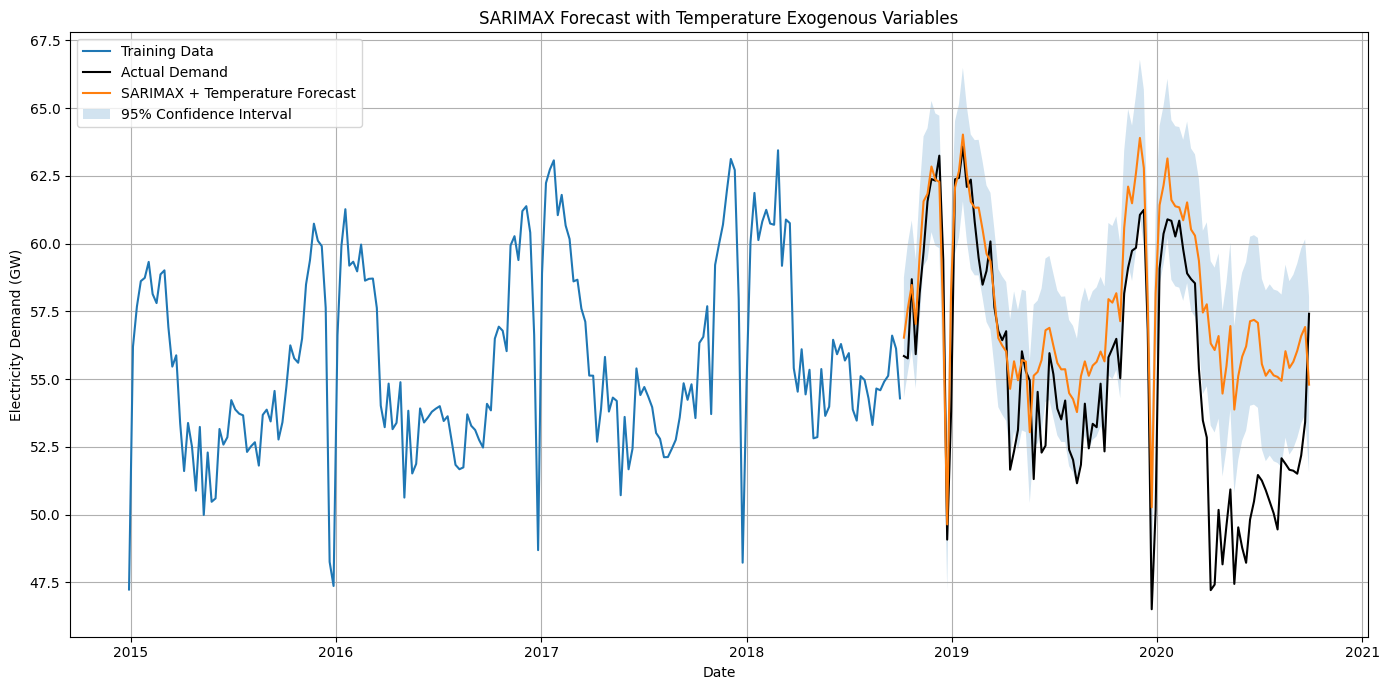

In [36]:

# SARIMAX + Temperature Forecast Plot


plt.figure(figsize=(14,7))


# Training data

plt.plot(
    y_train.index,
    y_train,
    label="Training Data"
)


# Actual test data

plt.plot(
    y_test.index,
    y_test,
    color="black",
    label="Actual Demand"
)


# SARIMAX temperature forecast

plt.plot(
    y_test.index,
    sarimax_temp_mean,
    label="SARIMAX + Temperature Forecast"
)


# 95% confidence interval

plt.fill_between(
    y_test.index,
    sarimax_temp_ci95.iloc[:,0],
    sarimax_temp_ci95.iloc[:,1],
    alpha=0.2,
    label="95% Confidence Interval"
)


plt.title(
    "SARIMAX Forecast with Temperature Exogenous Variables"
)

plt.xlabel("Date")
plt.ylabel("Electricity Demand (GW)")


plt.legend()
plt.grid()

plt.tight_layout()
plt.tight_layout()

plt.savefig(
    "SARIMAX_temperature_forecast.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.show()

In [37]:
# part5
# Import libraries
from sklearn.ensemble import HistGradientBoostingRegressor
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [38]:
# Combine electricity load and temperature features

weekly_df = weekly.to_frame(name="load_gw")

weekly_df.index = weekly_df.index.tz_localize(None)
temp_weekly.index = temp_weekly.index.tz_localize(None)

feature_data = weekly_df.join(temp_weekly, how="inner")

In [45]:
# Feature Engineering

def make_features(df):

    df = df.copy()

    # Target
    df["y"] = df["load_gw"]

    # Lag Features
    for lag in [1,2,4,8,13,26,52]:
        df[f"lag_{lag}"] = df["y"].shift(lag)

    # Rolling Statistics
    df["roll_mean_4"] = df["y"].shift(1).rolling(4).mean()
    df["roll_mean_13"] = df["y"].shift(1).rolling(13).mean()
    df["roll_mean_52"] = df["y"].shift(1).rolling(52).mean()
    df["roll_std_4"] = df["y"].shift(1).rolling(4).std()
    df["roll_std_13"] = df["y"].shift(1).rolling(13).std()

    # Calendar Features
    week = df.index.isocalendar().week.astype(int)
    df["week"] = week
    df["month"] = df.index.month
    df["year"] = df.index.year

    # Fourier Features
    for k in range(1,4):

        df[f"sin_{k}"] = np.sin(
            2*np.pi*k*week/52
        )

        df[f"cos_{k}"] = np.cos(
            2*np.pi*k*week/52
        )

    return df.dropna()

In [46]:
supervised = make_features(feature_data)

In [50]:
# Train/Test Split

train_supervised = supervised.loc[
    supervised.index <= train.index[-1].tz_localize(None)
]

test_supervised = supervised.loc[
    supervised.index >= test.index[0].tz_localize(None)
]

X_train = train_supervised.drop(columns=["load_gw","y"])
y_train = train_supervised["y"]

X_test = test_supervised.drop(columns=["load_gw","y"])
y_test = test_supervised["y"]

print(X_train.shape)
print(X_test.shape)


(145, 24)
(103, 24)


In [51]:
# Gradient Boosting Regressor

gbr = HistGradientBoostingRegressor(

    max_iter=500,

    learning_rate=0.03,

    max_leaf_nodes=15,

    random_state=42

)

gbr.fit(X_train,y_train)


HistGradientBoostingRegressor(learning_rate=0.03, max_iter=500,
                              max_leaf_nodes=15, random_state=42)

In [52]:
# Forecast

feature_forecast = pd.Series(

    gbr.predict(X_test),

    index=y_test.index,

    name="Feature Model"

)

In [56]:
# Evaluation

results.append(

    evaluate_forecast(

        "Feature Model",

        y_test,

        feature_forecast,

        train

    )

)
print(pd.DataFrame(results).sort_values("RMSE"))

                   model       MAE      RMSE      MASE      Bias
9          Feature Model  1.952989  2.660526  1.459263  1.183921
8          Feature Model  1.952989  2.660526  1.459263  1.183921
2         Seasonal naive  2.063028  2.671877  1.541484  1.440722
4                 SARIMA  2.133525  2.729623  1.594158  1.727384
7  SARIMAX + Temperature  2.745156  3.485304       NaN  2.527370
6  SARIMAX + Temperature  2.745156  3.485304       NaN  2.527370
5  SARIMAX + Temperature  2.745156  3.485304       NaN  2.527370
0                   Mean  3.788833  4.397300  2.830996  0.481006
1                  Naive  3.783203  4.459109  2.826789 -0.882480
3                  Drift  4.339891  5.117957  3.242743  1.006802


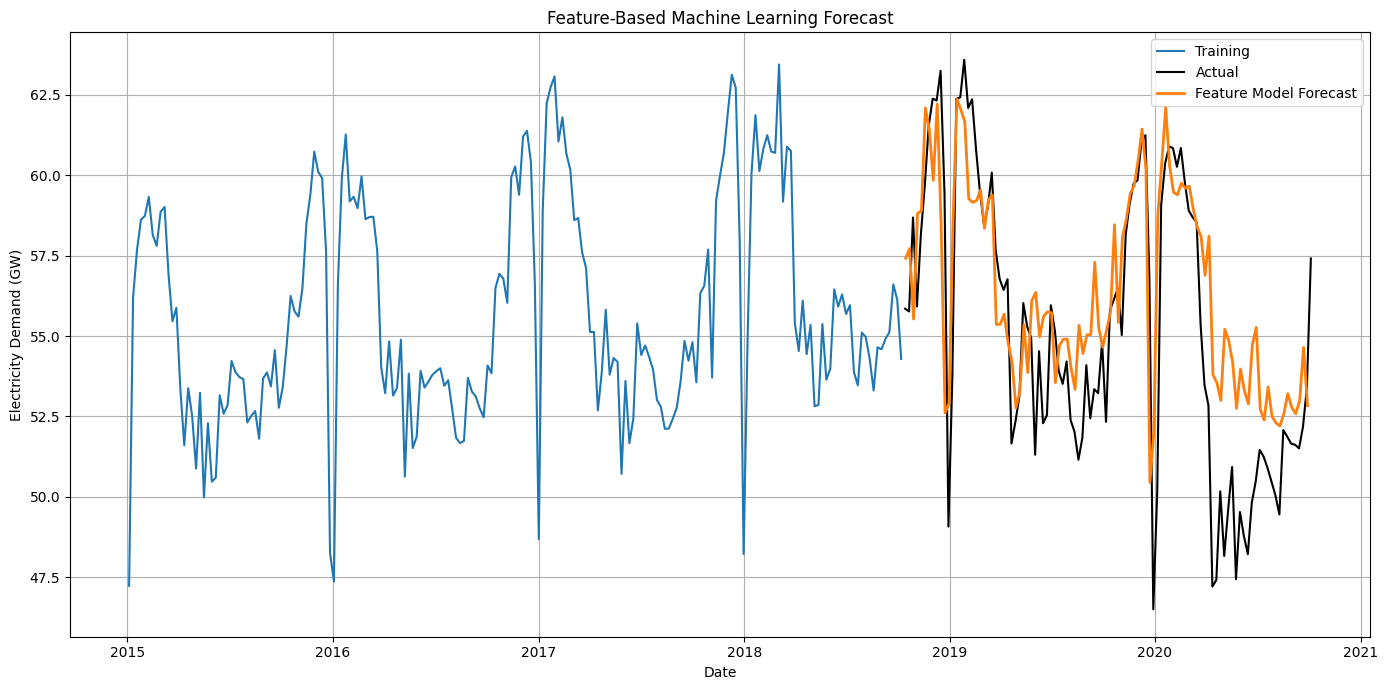

In [57]:
# Plot


plt.figure(figsize=(14,7))

plt.plot(
    train.index.tz_localize(None),
    train,
    label="Training"
)

plt.plot(
    test.index.tz_localize(None),
    test,
    color="black",
    label="Actual"
)

plt.plot(
    feature_forecast.index,
    feature_forecast,
    label="Feature Model Forecast",
    linewidth=2
)

plt.title("Feature-Based Machine Learning Forecast")

plt.xlabel("Date")

plt.ylabel("Electricity Demand (GW)")

plt.legend()

plt.grid()
plt.tight_layout()


# Save figure
plt.savefig(
    "Feature_Based_Machine_Learning_Forecast.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

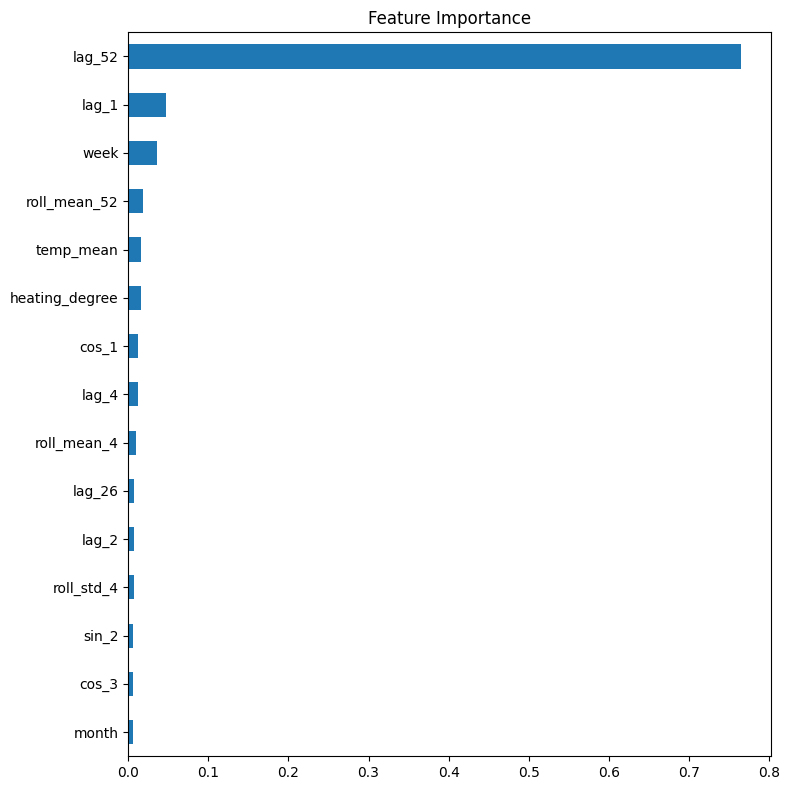

In [58]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=500,
    max_depth=12,
    random_state=42
)

rf.fit(X_train, y_train)

importance = pd.Series(
    rf.feature_importances_,
    index=X_train.columns
).sort_values()

plt.figure(figsize=(8,8))

importance.tail(15).plot(kind="barh")

plt.title("Feature Importance")

plt.tight_layout()

plt.show()

In [59]:
# part6

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

np.random.seed(0)
tf.random.set_seed(0)

In [60]:

# Part 6.1 Reload hourly electricity demand data

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


url = "https://data.open-power-system-data.org/time_series/2020-10-06/time_series_60min_singleindex.csv"


hourly_df = pd.read_csv(
    url,
    usecols=[
        "utc_timestamp",
        "DE_load_actual_entsoe_transparency"
    ],
    parse_dates=["utc_timestamp"]
)


hourly_df = hourly_df.rename(
    columns={
        "utc_timestamp": "date",
        "DE_load_actual_entsoe_transparency": "load_gw"
    }
)


hourly_df = hourly_df.set_index("date")

hourly_df = hourly_df.sort_index()


# Remove missing values

hourly_df = hourly_df.dropna()


# Convert MW to GW

hourly_df["load_gw"] = hourly_df["load_gw"] / 1000


# Keep data from 2015 onwards

hourly_df = hourly_df.loc["2015-01-01":]


# Create hourly load series

hourly_load = hourly_df["load_gw"]


print(hourly_load.head())

print("\nDataset size:")
print(hourly_load.shape)

date
2015-01-01 00:00:00+00:00    41.151
2015-01-01 01:00:00+00:00    40.135
2015-01-01 02:00:00+00:00    39.106
2015-01-01 03:00:00+00:00    38.765
2015-01-01 04:00:00+00:00    38.941
Name: load_gw, dtype: float64

Dataset size:
(50400,)


In [61]:

# Part 6.2 Train-test split

test_hours = 24 * 365 * 2


train = hourly_load.iloc[:-test_hours]

test = hourly_load.iloc[-test_hours:]


print("Training:", train.shape)
print("Testing :", test.shape)

print("\nTrain period:")
print(train.index.min(), "to", train.index.max())

print("\nTest period:")
print(test.index.min(), "to", test.index.max())

Training: (32880,)
Testing : (17520,)

Train period:
2015-01-01 00:00:00+00:00 to 2018-10-01 23:00:00+00:00

Test period:
2018-10-02 00:00:00+00:00 to 2020-09-30 23:00:00+00:00


In [62]:

# Part 6.3 Scaling data for LSTM

from sklearn.preprocessing import MinMaxScaler


scaler = MinMaxScaler()


train_scaled = scaler.fit_transform(
    train.values.reshape(-1, 1)
)


test_scaled = scaler.transform(
    test.values.reshape(-1, 1)
)


print("Train scaled shape:", train_scaled.shape)
print("Test scaled shape :", test_scaled.shape)

Train scaled shape: (32880, 1)
Test scaled shape : (17520, 1)


In [63]:

# Part 6.4 Create LSTM sequences


def create_sequences(data, window):

    X = []
    y = []

    for i in range(window, len(data)):

        X.append(
            data[i-window:i]
        )

        y.append(
            data[i]
        )

    return np.array(X), np.array(y)



window = 168   # previous one week


# Training sequences

X_train, y_train = create_sequences(
    train_scaled,
    window
)


# Test sequences
# Include previous 168 hours from training for first prediction

combined = np.concatenate(
    [
        train_scaled[-window:],
        test_scaled
    ]
)


X_test, y_test = create_sequences(
    combined,
    window
)


print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_test :", X_test.shape)
print("y_test :", y_test.shape)

X_train: (32712, 168, 1)
y_train: (32712, 1)
X_test : (17520, 168, 1)
y_test : (17520, 1)


In [65]:

# Part 6.5 Build LSTM Model


from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

model = Sequential()

model.add(
    LSTM(
        units=64,
        input_shape=(window, 1)
    )
)

model.add(
    Dropout(0.2)
)

model.add(
    Dense(1)
)

model.compile(
    optimizer="adam",
    loss="mse"
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,961 (66.25 KB)

 Trainable params: 16,961 (66.25 KB)

 Non-trainable params: 0 (0.00 B)

In [66]:
# Part 6.6 Train LSTM


early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/30
409/409 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - loss: 0.0172 - val_loss: 0.0033
Epoch 2/30
409/409 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - loss: 0.0048 - val_loss: 0.0021
Epoch 3/30
409/409 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.0035 - val_loss: 0.0017
Epoch 4/30
409/409 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0028 - val_loss: 0.0014
Epoch 5/30
409/409 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.0025 - val_loss: 0.0011
Epoch 6/30
409/409 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.0021 - val_loss: 9.8197e-04
Epoch 7/30
409/409 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0018 - val_loss: 7.5508e-04
Epoch 8/30
409/409 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0015 - val_loss: 7.5678e-04
Epoch 9/30
409/409 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.0014 - val_loss: 6.0572e-04
Epoch 10/30
409/409 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0012 - val_loss: 6.0392e-04
Epoch 11/30
409/409 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0012 - val_loss: 5.8342e-04
Epoch 12/30
409/4

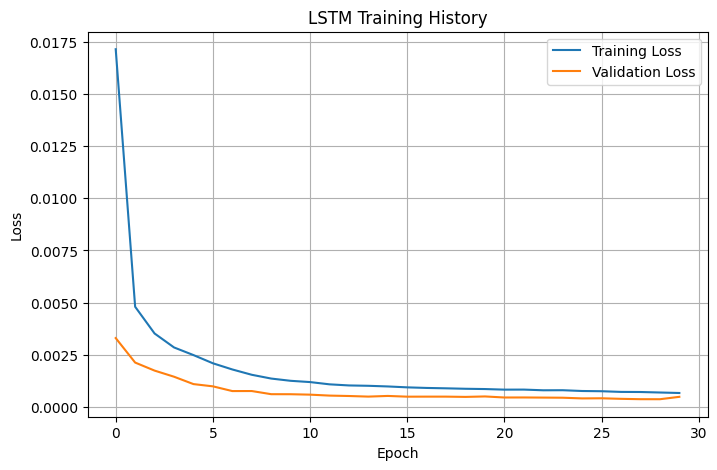

In [67]:

# Part 6.7 Training History
#

plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("LSTM Training History")

plt.legend()
plt.grid()

plt.show()

In [68]:

# Part 6.8 Forecast

prediction_scaled = model.predict(X_test)

prediction = scaler.inverse_transform(prediction_scaled)

actual = scaler.inverse_transform(y_test)

print(prediction.shape)
print(actual.shape)

548/548 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
(17520, 1)
(17520, 1)


In [69]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

rmse = np.sqrt(
    mean_squared_error(
        actual,
        prediction
    )
)

mae = mean_absolute_error(
    actual,
    prediction
)

print("LSTM RMSE:", rmse)
print("LSTM MAE :", mae)

LSTM RMSE: 0.9078106248394818
LSTM MAE : 0.6930535773394859


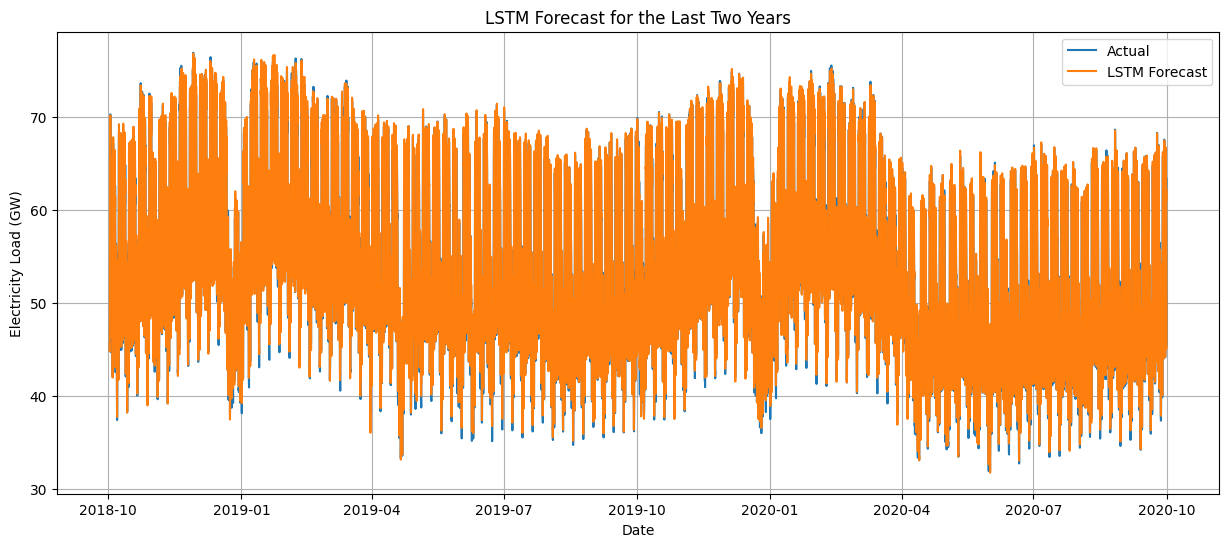

In [70]:
# Full 2-year forecast
plt.figure(figsize=(15,6))

plt.plot(test.index, actual, label="Actual")
plt.plot(test.index, prediction, label="LSTM Forecast")

plt.title("LSTM Forecast for the Last Two Years")
plt.xlabel("Date")
plt.ylabel("Electricity Load (GW)")
plt.legend()
plt.grid()

plt.show()

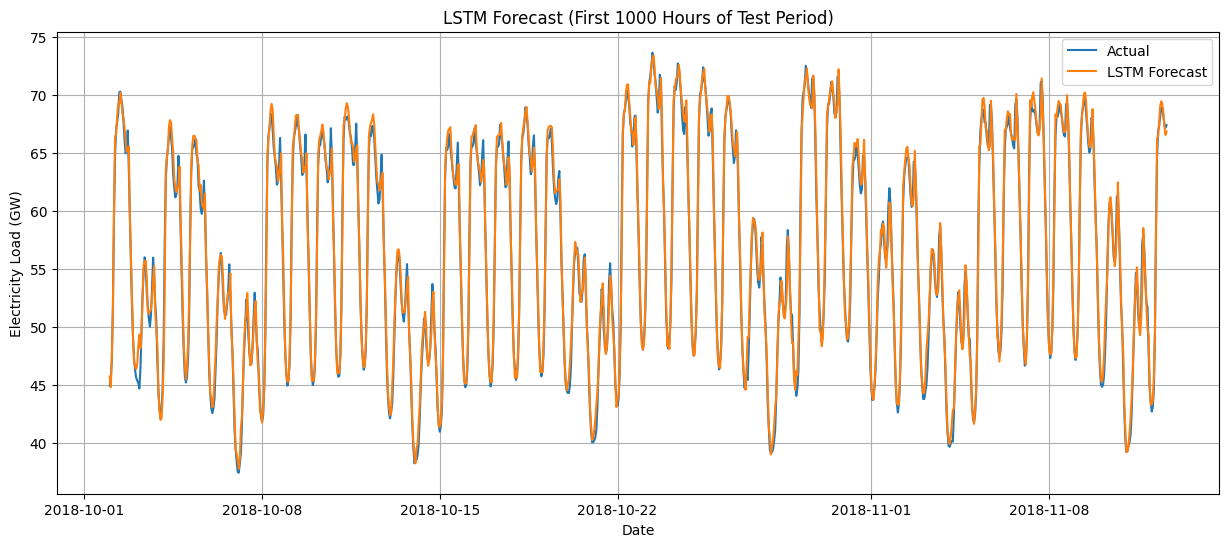

In [71]:
# Zoomed-in forecast
plt.figure(figsize=(15,6))

plt.plot(test.index[:1000], actual[:1000], label="Actual")
plt.plot(test.index[:1000], prediction[:1000], label="LSTM Forecast")

plt.title("LSTM Forecast (First 1000 Hours of Test Period)")
plt.xlabel("Date")
plt.ylabel("Electricity Load (GW)")
plt.legend()
plt.grid()

plt.show()

In [72]:
# Hyperparameter Tuning
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.layers import Input
from tensorflow.keras.callbacks import EarlyStopping


def build_lstm(units=64, layers=1, dropout=0.2):

    model = Sequential()

    model.add(
        Input(shape=(window,1))
    )

    # First LSTM layer
    model.add(
        LSTM(
            units,
            return_sequences=(layers > 1)
        )
    )

    model.add(
        Dropout(dropout)
    )


    # Second LSTM layer if required
    if layers > 1:

        model.add(
            LSTM(units)
        )

        model.add(
            Dropout(dropout)
        )


    model.add(
        Dense(1)
    )


    model.compile(
        optimizer="adam",
        loss="mse"
    )


    return model

In [73]:

# Part 6: LSTM Hyperparameter Tuning
# Compare different layer sizes

import numpy as np
import pandas as pd
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import mean_squared_error, mean_absolute_error


# Fix random seed
np.random.seed(0)
tf.random.set_seed(0)


# LSTM model builder


def build_lstm_model(units, layers, dropout_rate=0.2):

    model = Sequential()

    # First layer
    model.add(
        Input(shape=(X_train.shape[1], X_train.shape[2]))
    )

    model.add(
        LSTM(
            units,
            return_sequences=(layers > 1)
        )
    )

    model.add(Dropout(dropout_rate))


    # Additional LSTM layer
    if layers == 2:
        model.add(
            LSTM(units)
        )
        model.add(Dropout(dropout_rate))


    # Output layer
    model.add(Dense(1))


    model.compile(
        optimizer="adam",
        loss="mse"
    )

    return model



# Hyperparameter configurations

configs = [
    ("LSTM-32",32,1,0.2),
    ("LSTM-64",64,1,0.2),
    ("LSTM-64-64",64,2,0.2)
]


results_lstm = []


# Store predictions
predictions = {}



# Train and evaluate each model
for name, units, layers, dropout in configs:

    print("\nTraining:", name)


    model = build_lstm_model(
        units,
        layers,
        dropout
    )


    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    )


    history = model.fit(
        X_train,
        y_train,
        epochs=15,
        batch_size=64,
        validation_split=0.1,
        callbacks=[early_stop],
        verbose=1
    )


    # Forecast
    pred_scaled = model.predict(
        X_test
    )


    # Convert back to GW scale
    pred = scaler.inverse_transform(
        pred_scaled
    )


    actual = scaler.inverse_transform(
        y_test.reshape(-1,1)
    )


    predictions[name] = pred.flatten()


    # Metrics
    rmse = np.sqrt(
        mean_squared_error(
            actual,
            pred
        )
    )

    mae = mean_absolute_error(
        actual,
        pred
    )


    results_lstm.append(
        {
            "Model": name,
            "RMSE": rmse,
            "MAE": mae
        }
    )



# Results table


lstm_results = pd.DataFrame(results_lstm)

print("\nLSTM Hyperparameter Results")
print(lstm_results.sort_values("RMSE"))


Training: LSTM-32
Epoch 1/15
460/460 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 0.0202 - val_loss: 0.0054
Epoch 2/15
460/460 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0076 - val_loss: 0.0027
Epoch 3/15
460/460 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0049 - val_loss: 0.0012
Epoch 4/15
460/460 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0035 - val_loss: 8.5930e-04
Epoch 5/15
460/460 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0028 - val_loss: 8.6165e-04
Epoch 6/15
460/460 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0023 - val_loss: 5.9083e-04
Epoch 7/15
460/460 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0019 - val_loss: 5.6539e-04
Epoch 8/15
460/460 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0017 - val_loss: 5.2180e-04
Epoch 9/15
460/460 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0015 - val_loss: 4.7455e-04
Epoch 10/15
460/460 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0014 - val_loss: 4.8837e-04
Epoch 11/15
460/460 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.0013 - val_loss: 4.4761e-0